In [1]:
import torch

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Training RNNs

## Forecasting a Time Series

Let's download the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://homl.info/ridership).

In [4]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

Now let's clean up the data a bit:

In [5]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [6]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

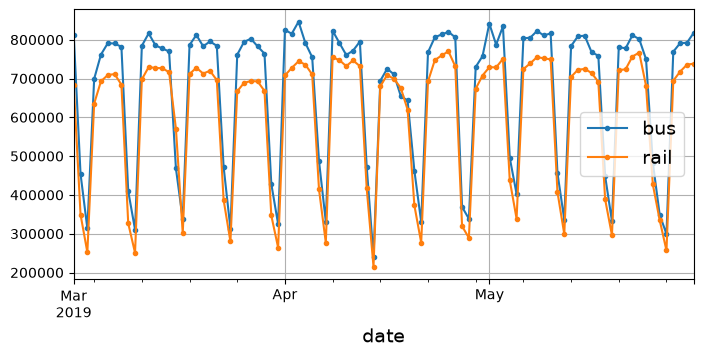

In [7]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

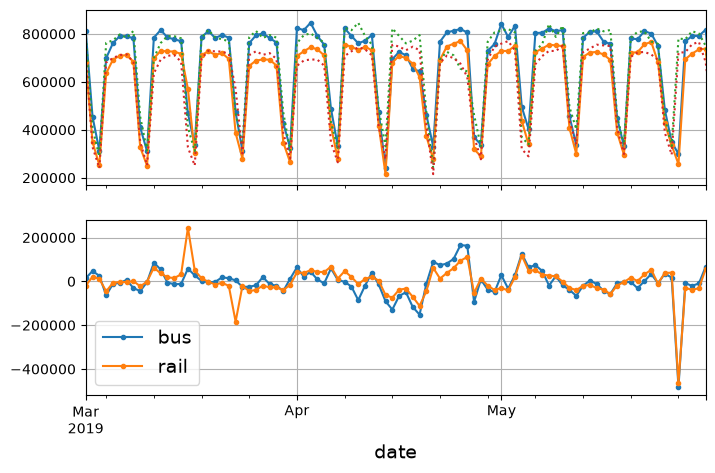

In [8]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [9]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

Mean absolute error (MAE), also called mean absolute deviation (MAD):

In [10]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

Mean absolute percentage error (MAPE):

In [11]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Now let's look at the yearly seasonality and the long-term trends:

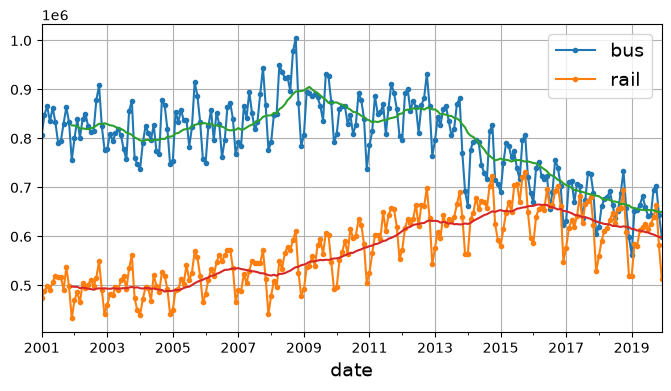

In [12]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

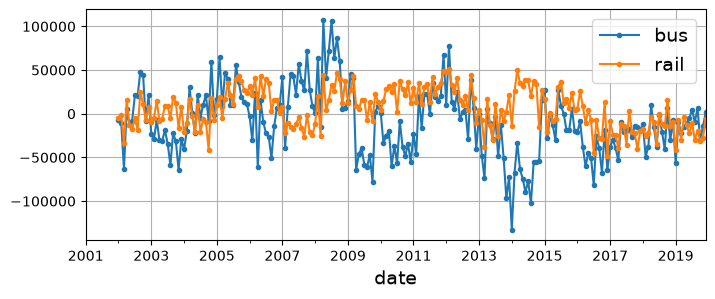

In [13]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

## Preparing the Data for Machine Learning Models

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [16]:
my_series = torch.tensor([
    [0], 
    [1], 
    [2], 
    [3], 
    [4], 
    [5]
])
my_dataset = TimeSeriesDataset(my_series, window_length=3)
for window, target in my_dataset:
    print("Window:", window, " Target:", target)

Window: tensor([[0],
        [1],
        [2]])  Target: tensor([3])
Window: tensor([[1],
        [2],
        [3]])  Target: tensor([4])
Window: tensor([[2],
        [3],
        [4]])  Target: tensor([5])


In [17]:
from torch.utils.data import DataLoader
torch.manual_seed(0)
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)
for X, y in my_loader:
    print("X:", X, " y:", y)

X: tensor([[[0],
         [1],
         [2]],

        [[2],
         [3],
         [4]]])  y: tensor([[3],
        [5]])
X: tensor([[[1],
         [2],
         [3]]])  y: tensor([[4]])


Before we continue looking at the data, let's split the time series into three periods, for training, validation and testing. We won't look at the test data for now:

In [18]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [19]:
window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [ ]:
# import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

# def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
#           n_epochs, patience=10, factor=0.1):
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode="min", patience=patience, factor=factor)
#     history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
#     for epoch in range(n_epochs):
#         total_loss = 0.0
#         metric.reset()
#         model.train()
#         for X_batch, y_batch in train_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             y_pred = model(X_batch)
#             loss = loss_fn(y_pred, y_batch)
#             total_loss += loss.item()
#             loss.backward()
#             optimizer.step()
#             optimizer.zero_grad()
#             metric.update(y_pred, y_batch)
#         history["train_losses"].append(total_loss / len(train_loader))
#         history["train_metrics"].append(metric.compute().item())
#         val_metric = evaluate_tm(model, valid_loader, metric).item()
#         history["valid_metrics"].append(val_metric)
#         scheduler.step(val_metric)
#         print(f"Epoch {epoch + 1}/{n_epochs}, "
#               f"train loss: {history['train_losses'][-1]:.4f}, "
#               f"train metric: {history['train_metrics'][-1]:.4f}, "
#               f"valid metric: {history['valid_metrics'][-1]:.4f}")
#     return history

In [21]:
from custom_utils import train, plot_history

In [23]:
len(train_set)

1040

In [ ]:
(32, 56, 1)

In [29]:
(6.25/2 + 7)/2

5.0625

In [ ]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(), 
    nn.Linear(window_length, 1)
).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
    optimizer, 
    loss_fn, 
    metric, 
    train_loader,
    valid_loader, 
    n_epochs=50,
    device=device
)

Epoch: 1/50, Train Loss: 0.015, Train Metric: 0.146, Valid Metric: 0.123, Time: 0.4s
	Checkpoint, valid metric: 0.123
Epoch: 2/50, Train Loss: 0.01, Train Metric: 0.112, Valid Metric: 0.1, Time: 0.14s
	Checkpoint, valid metric: 0.100
Epoch: 3/50, Train Loss: 0.008, Train Metric: 0.093, Valid Metric: 0.079, Time: 0.15s
	Checkpoint, valid metric: 0.079
Epoch: 4/50, Train Loss: 0.006, Train Metric: 0.082, Valid Metric: 0.067, Time: 0.13s
	Checkpoint, valid metric: 0.067
Epoch: 5/50, Train Loss: 0.006, Train Metric: 0.074, Valid Metric: 0.061, Time: 0.17s
	Checkpoint, valid metric: 0.061
Epoch: 6/50, Train Loss: 0.005, Train Metric: 0.07, Valid Metric: 0.055, Time: 0.14s
	Checkpoint, valid metric: 0.055
Epoch: 7/50, Train Loss: 0.005, Train Metric: 0.066, Valid Metric: 0.054, Time: 0.15s
	Checkpoint, valid metric: 0.054
Epoch: 8/50, Train Loss: 0.005, Train Metric: 0.064, Valid Metric: 0.049, Time: 0.14s
	Checkpoint, valid metric: 0.049
Epoch: 9/50, Train Loss: 0.005, Train Metric: 0.062, 

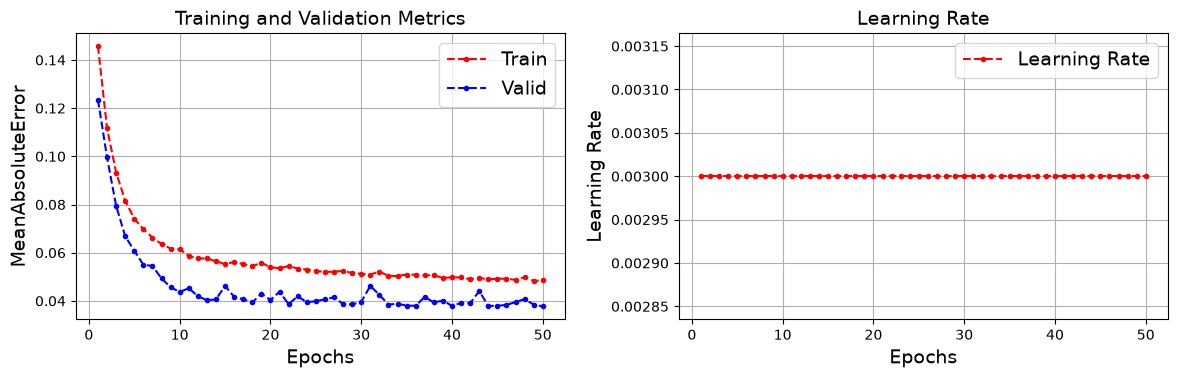

In [24]:
plot_history(history, metric)

In [34]:
evaluate_tm(model, valid_loader, metric).item() * 1e6

37725.720554590225

In [38]:
class Heyvan:
    def __init__(self, nov):
        self.nov = nov
        self.yasayir = True

class It(Heyvan):
    def __init__(self):
        super().__init__(nov='it')
        self.sahibi = None

it1 = It()
it1.sahibi is None

True

In [49]:
X_batch, y_batch = next(iter(train_loader))
X_batch.permute([1,0,2]).shape

torch.Size([56, 32, 1])

In [52]:
class CustomRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size

        self.hidden_layer = nn.Sequential(
            nn.Linear(
                in_features=input_size + hidden_size , 
                out_features=hidden_size),
            nn.Tanh()
        )

        self.output_layer = nn.Linear(
            in_features=hidden_size, 
            out_features=output_size
        )

    def forward(self, X_batch):
        batch_size, window_length, dimensionality = X_batch.shape # [32, 56, 1]
        X_time_first = X_batch.permute([1,0,2]) # [56, 32, 1]

        Y = torch.zeros(batch_size, self.hidden_size).to(device) # (32, 3)

        for X_t in X_time_first: # (32, 1) -> 56 times
            XY = torch.concat([X_t, Y], dim=1) # (32, 4)
            Y = self.hidden_layer(XY) # (32, 3)

        y_pred = self.output_layer(Y) # (32, 1)

        return y_pred
        

model = CustomRNNModel(input_size = 1, hidden_size = 3, output_size = 1).to(device)

In [53]:
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
    optimizer, 
    loss_fn, 
    metric, 
    train_loader,
    valid_loader, 
    n_epochs=50,
    device=device
)

Epoch: 1/50, Train Loss: 0.099, Train Metric: 0.386, Valid Metric: 0.16, Time: 1.73s
	Checkpoint, valid metric: 0.160
Epoch: 2/50, Train Loss: 0.016, Train Metric: 0.154, Valid Metric: 0.131, Time: 0.7s
	Checkpoint, valid metric: 0.131
Epoch: 3/50, Train Loss: 0.016, Train Metric: 0.153, Valid Metric: 0.139, Time: 0.68s
Epoch: 4/50, Train Loss: 0.016, Train Metric: 0.157, Valid Metric: 0.14, Time: 0.68s
Epoch: 5/50, Train Loss: 0.015, Train Metric: 0.156, Valid Metric: 0.139, Time: 0.8s
Epoch: 6/50, Train Loss: 0.016, Train Metric: 0.156, Valid Metric: 0.138, Time: 0.72s
Epoch: 7/50, Train Loss: 0.015, Train Metric: 0.156, Valid Metric: 0.139, Time: 0.71s
Epoch: 8/50, Train Loss: 0.016, Train Metric: 0.155, Valid Metric: 0.137, Time: 0.7s
Epoch: 9/50, Train Loss: 0.015, Train Metric: 0.156, Valid Metric: 0.139, Time: 0.78s
Epoch: 10/50, Train Loss: 0.015, Train Metric: 0.155, Valid Metric: 0.138, Time: 0.71s
Epoch: 11/50, Train Loss: 0.015, Train Metric: 0.154, Valid Metric: 0.137, Tim